## Planteamiento de Problema: Predicción de organos en pacientes.

En México, miles de personas esperan un trasplante de órgano vital como el riñón o la córnea, lo que representa un reto importante para el sistema de salud. La clasificación y priorización de estos pacientes suele realizarse de forma manual, lo que puede generar demoras, errores o desigualdades en la asignación.
Frente a esta situación, proponemos el desarrollo de un modelo predictivo basado en redes neuronales que, a partir de variables como sexo, grupo sanguíneo, factor RH y edad, sea capaz de predecir con precisión si un paciente requiere un trasplante de riñón o córnea.
Este modelo busca apoyar la toma de decisiones médicas, optimizando los procesos de clasificación en la lista de espera y contribuyendo a una distribución más equitativa y eficiente de los órganos disponibles.

In [3]:
# Importar librerias necesarias

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

In [4]:
# Cargar el archivo .csv con los datos de pacientes
df = pd.read_csv("CENATRA_59_Pacientes_espera1erTrimestre2025.csv")

## Exploración Inicial 

## ¿Que estados tienen más pacientes en lista de espera?

In [7]:
estado_counts = df["entidad_federativa_establecimiento"].value_counts()

In [8]:
# Mostrar los 10 estados con mas pacientes en espera
print("Top de los 10 estados con más pacientes en espera de órganos:")
print(estado_counts.head(10))

Top de los 10 estados con más pacientes en espera de órganos:
entidad_federativa_establecimiento
Jalisco             6602
Ciudad de México    3022
Puebla              2003
Guanajuato          1949
Coahuila            1793
Nuevo León           868
Veracruz             762
San Luis Potosí      231
Yucatán              228
Sonora               227
Name: count, dtype: int64


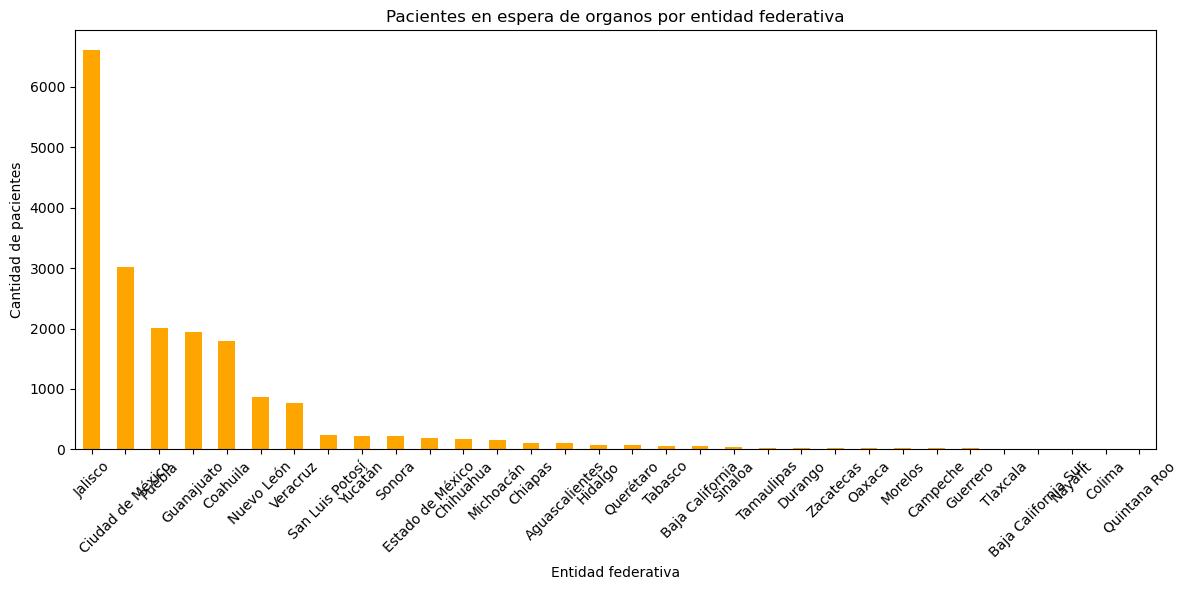

In [9]:
# Grafica de barras
plt.figure(figsize=(12,6))
estado_counts.plot(kind="bar", color="orange")
plt.title("Pacientes en espera de organos por entidad federativa")
plt.xlabel("Entidad federativa")
plt.ylabel("Cantidad de pacientes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

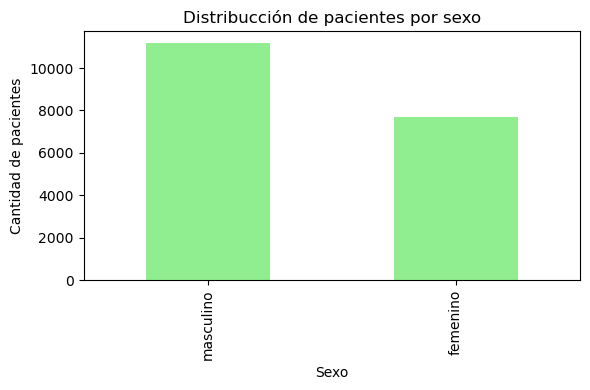

In [10]:
# Distribución de pacientes por sexo
sexo_counts = df["sexo"].value_counts()
plt.figure(figsize=(6,4))
sexo_counts.plot(kind="bar", color ="lightgreen")
plt.title("Distribucción de pacientes por sexo")
plt.xlabel("Sexo")
plt.ylabel("Cantidad de pacientes")
plt.xticks()
plt.tight_layout()
plt.show()

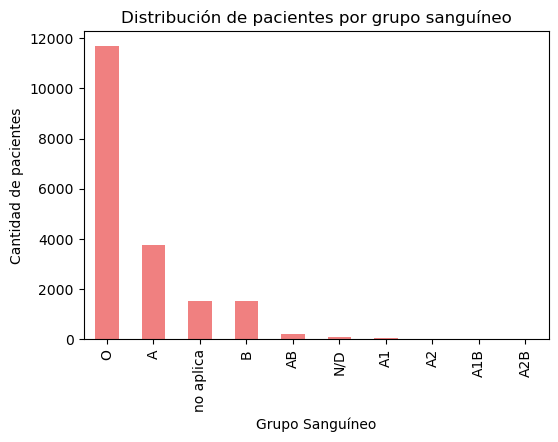

In [11]:
# Distribución de grupo sanguíneo
grupo_counts = df["grupo_sanguineo"].value_counts()
plt.figure(figsize=(6,4))
grupo_counts.plot(kind="bar", color="lightcoral")
plt.title("Distribución de pacientes por grupo sanguíneo")
plt.xlabel("Grupo Sanguíneo")
plt.ylabel("Cantidad de pacientes")
plt.show()

In [12]:
# Calcular la edad de los pacientes
from datetime import datetime
df["fecha_nacimiento"] = pd.to_datetime(df["fecha_nacimiento"], errors="coerce")
df = df[df["fecha_nacimiento"].notnull()] # Eliminar filas con fechas invalidas
df["edad"] = datetime.now().year - df["fecha_nacimiento"].dt.year # calculamos la edad

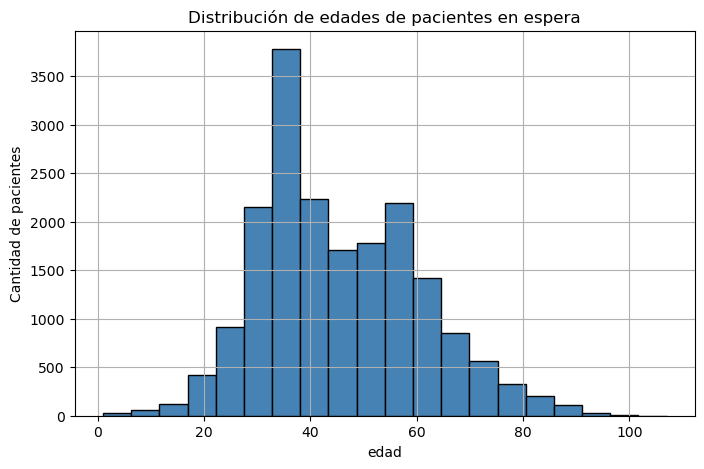

In [13]:
# Distribución de edades
plt.figure(figsize=(8,5))
df["edad"].hist(bins=20, color="steelblue", edgecolor="black")
plt.title("Distribución de edades de pacientes en espera")
plt.xlabel("edad")
plt.ylabel("Cantidad de pacientes")
plt.show()

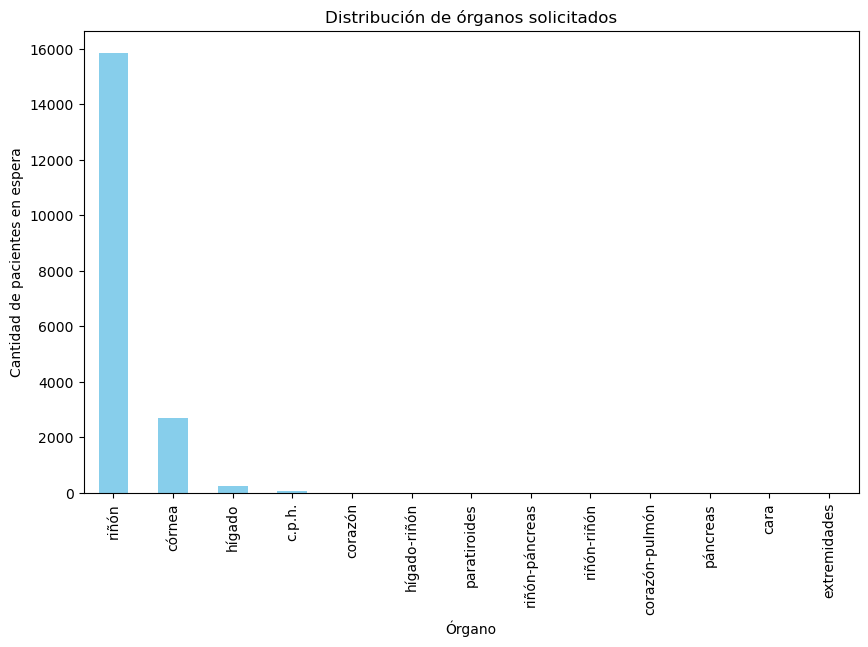

In [14]:
# Grafica de distribución de organos solicitados

organo_counts= df["organo"].value_counts()

plt.figure(figsize=(10,6))
organo_counts.plot(kind="bar", color="skyblue")
plt.title("Distribución de órganos solicitados")
plt.xlabel("Órgano")
plt.ylabel("Cantidad de pacientes en espera")
plt.show()

In [15]:
df["organo"].value_counts()

organo
riñón             15848
córnea             2683
hígado              242
c.p.h.               72
corazón              14
hígado-riñón          9
paratiroides          7
riñón-páncreas        5
riñón-riñón           1
corazón-pulmón        1
páncreas              1
cara                  1
extremidades          1
Name: count, dtype: int64

## Preprocesamiento 

In [17]:
# Seleccionar las columnas más relevantes para el modelo
features = ["sexo","grupo_sanguineo","rh","edad"]
target = "organo"

In [18]:
# Eliminar filas con datos faltantes
df = df[features + [target]].dropna()

In [19]:
# Codificar las variables categoricas a valores numéricos
label_encoders = {}
for col in ["sexo", "grupo_sanguineo","rh"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col]) # transformar texto a números
    label_encoders[col] = le

In [20]:
# codificar la variable objetivo (tipo de organo solicitado)
target_encoder = LabelEncoder()
df[target] = target_encoder.fit_transform(df[target])

In [21]:
n_clases = len(target_encoder.classes_)
print(f"Número de clases: {n_clases}")
print("Órganos:",target_encoder.classes_)

Número de clases: 13
Órganos: ['c.p.h.' 'cara' 'corazón' 'corazón-pulmón' 'córnea' 'extremidades'
 'hígado' 'hígado-riñón' 'paratiroides' 'páncreas' 'riñón'
 'riñón-páncreas' 'riñón-riñón']


In [22]:
# Separar las variables predictoras (X)  y la variable objetivo (y)
X= df[features].values
y = to_categorical(df[target].values) # One-hot encoding para clasificación multiclase


In [23]:
# Escalar los datos númericos
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [24]:
# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [25]:
X_train.shape[1]

4

In [26]:
y.shape[1]

13

## Crear el modelo utilizando Keras 

In [28]:
model = Sequential()
model.add(Dense(64, activation="relu", input_shape=(X_train.shape[1],))) # Capa oculta 1
model.add(Dropout(0.3)) # Regularización para evitar sobreajuste 
model.add(Dense(32,activation="relu")) # capa oculta 2
model.add(Dropout(0.3)) 
model.add(Dense(y.shape[1],activation="softmax")) # Capa de salida para clasificación multiclase

# loss="categorical_crossentropy" es la función de perdida usada para problemas de clasificación multiclase
# metrics=["accuracy"] Es la metrica para medir la precisión del modelo durante todo el proceso de entrenamiento y validación
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# batch_size=16 indica al modelo que va a procesar los datos en bloques de 16 muestras antes de actualizar los pesos
model.fit(X_train, y_train, epochs=30, batch_size=16, validation_split=0.2)


Epoch 1/30
756/756 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7775 - loss: 0.9575 - val_accuracy: 0.9014 - val_loss: 0.3595
Epoch 2/30
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9093 - loss: 0.3749 - val_accuracy: 0.9186 - val_loss: 0.3446
Epoch 3/30
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9196 - loss: 0.3486 - val_accuracy: 0.9203 - val_loss: 0.3166
Epoch 4/30
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9227 - loss: 0.3197 - val_accuracy: 0.9212 - val_loss: 0.3141
Epoch 5/30
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9277 - loss: 0.3137 - val_accuracy: 0.9206 - val_loss: 0.3104
Epoch 6/30
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9273 - loss: 0.3018 - val_accuracy: 0.9219 - val_loss: 0.3107
Epoch 7/30
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9257 - loss: 0.3095 - val_accuracy: 0.9222 - val_loss: 0.3084
Epoch 8/30
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9260 - loss: 0.3047 - val_accuracy: 0.

In [29]:
# Evaluar el modelo con los datos de prueba
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Precisión en test:{accuracy:.2f}")

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9394 - loss: 0.2414
Precisión en test:0.94


## Simular agregar un nuevo paciente

In [31]:
nuevo_paciente={
    "sexo":"masculino",
    "grupo_sanguineo":"O",
    "rh":"positivo",
    "edad": 70
}

In [32]:
# Codificar el nuevo paciente
nuevo_paciente["sexo"] = label_encoders["sexo"].transform([nuevo_paciente["sexo"]])[0]
nuevo_paciente["grupo_sanguineo"] = label_encoders["grupo_sanguineo"].transform([nuevo_paciente["grupo_sanguineo"]])[0]
nuevo_paciente["rh"] = label_encoders["rh"].transform([nuevo_paciente["rh"]])[0]

In [33]:
# convertir  Y Escalar 
import numpy as np
X_nuevo = np.array([[nuevo_paciente["sexo"],nuevo_paciente["grupo_sanguineo"],nuevo_paciente["rh"], nuevo_paciente["edad"]]])
X_nuevo = scaler.transform(X_nuevo)

In [34]:
X_nuevo

array([[0.83062199, 0.53938944, 0.35063962, 1.63511817]])

In [35]:
# Predecir organo
prediccion = model.predict(X_nuevo)
organo_predicho = target_encoder.inverse_transform([np.argmax(prediccion)])[0]
print(f"Organo predicho para este paciente: {organo_predicho}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Organo predicho para este paciente: riñón


In [36]:
# Mostrar la probalidad de cada clase 
for clase, prob in zip(target_encoder.classes_,prediccion[0]):
    print(f"{clase}:{prob:.2f}")

c.p.h.:0.01
cara:0.00
corazón:0.00
corazón-pulmón:0.00
córnea:0.18
extremidades:0.00
hígado:0.01
hígado-riñón:0.00
paratiroides:0.00
páncreas:0.00
riñón:0.79
riñón-páncreas:0.00
riñón-riñón:0.00


### 🩺 1. Identificación de patrones poblacionales relevantes
El modelo entrenado permite identificar correlaciones estadísticas entre el perfil demográfico y sanguíneo de los pacientes y el tipo de órgano que suelen requerir. Por ejemplo:

Personas mayores tienden a solicitar riñón.

Pacientes jóvenes con ciertos grupos sanguíneos aparecen con mayor frecuencia en solicitudes de córnea.

Estos patrones pueden ser utilizados para:

✅ Anticipar demanda de órganos
✅ Generar alertas preventivas en poblaciones vulnerables
✅ Enfocar campañas de prevención renal o visual por grupo etario

### 📊 2. Mejora en la planificación de recursos sanitarios
Con este modelo, instituciones como el CENATRA pueden:

Estimar la demanda futura de órganos por perfil poblacional.

Asignar recursos logísticos, médicos y presupuestales según la prevalencia de necesidades detectadas.


### 📌 Reflexión final
Esta red neuronal no sustituye una evaluación médica real, pero podría:

Ser útil como herramienta exploratoria en salud pública.

Ayudar a detectar tendencias en las listas de espera.

Contribuir al diseño de campañas de donación de órganos más efectivas segmentando por perfil demográfico.

### Url de recuperacion de datos 
https://datos.gob.mx/dataset/pacientes_espera_organo_tejido